
# Markov Chains: A Step‑by‑Step Tutorial (Colab Ready)

This notebook introduces discrete-time, finite-state Markov chains through a sequence of
conceptual explanations and concrete implementations.

**What you'll do:**
1. Define and validate transition matrices.
2. Compute n-step transitions and state distributions.
3. Simulate sample paths.
4. Find stationary distributions and study convergence.
5. Analyze hitting times and absorption.
6. Work an absorbing-chain example with the fundamental matrix.
7. (Optional) Explore a tiny PageRank-style Markov chain.

**How to use:** In Colab, go to **Runtime → Run all**. Cells are annotated and can be run individually.


In [ ]:

import numpy as np
import numpy.linalg as nla
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(42)

def _err(place, e):
    import traceback
    print(f"[{place}] {e}")
    traceback.print_exc()



## 1. Fundamentals

A (row-stochastic) transition matrix P for a finite Markov chain with states {0,1,...,m-1} satisfies:

- $P[i,j] >= 0$ for all i,j,
- $\sum_j P[i,j]$ = 1 for each row i.

If $pi_0$ is an initial row distribution (nonnegative, sums to 1), then the distribution after k steps is
$pi_k = pi_0 P_k$.

We begin with utilities to validate and work with Markov chains.


In [ ]:

def check_stochastic_matrix(P, atol=1e-12):
    P = np.asarray(P, dtype=float)
    diags = {}
    try:
        diags["shape"] = P.shape
        diags["min_entry"] = P.min()
        diags["max_entry"] = P.max()
        diags["row_sums"] = P.sum(axis=1)
        diags["row_sum_close_to_1"] = np.allclose(diags["row_sums"], 1.0, atol=atol)
        diags["all_entries_in_[0,1]"] = (diags["min_entry"] >= -atol) and (diags["max_entry"] <= 1+atol)
        diags["is_square"] = (P.ndim == 2) and (P.shape[0] == P.shape[1])
        diags["is_stochastic"] = diags["is_square"] and diags["row_sum_close_to_1"] and diags["all_entries_in_[0,1]"]
        return diags
    except Exception as e:
        _err("check_stochastic_matrix", e)
        raise

def normalize_distribution(pi, atol=1e-12):
    try:
        pi = np.asarray(pi, dtype=float).reshape(-1)
        if (pi < -atol).any():
            raise ValueError("Distribution contains negative entries.")
        s = pi.sum()
        if s <= atol:
            raise ValueError("Sum of probabilities is ~0; cannot normalize.")
        return pi / s
    except Exception as e:
        _err("normalize_distribution", e)
        raise

def nstep_transition(P, n):
    try:
        return nla.matrix_power(np.asarray(P, float), int(n))
    except Exception as e:
        _err("nstep_transition", e)
        raise

def advance_distribution(pi0, P, k):
    try:
        pi0 = normalize_distribution(pi0)
        Pk = nstep_transition(P, k)
        return pi0 @ Pk
    except Exception as e:
        _err("advance_distribution", e)
        raise



## 2. Example I — A Simple Weather Chain

States: S = {Sunny (0), Cloudy (1), Rainy (2)} with a transition model:

- If today is Sunny: tomorrow Sunny=0.7, Cloudy=0.2, Rainy=0.1
- If today is Cloudy: tomorrow Sunny=0.3, Cloudy=0.4, Rainy=0.3
- If today is Rainy: tomorrow Sunny=0.2, Cloudy=0.3, Rainy=0.5

We validate the matrix, compute multi-step transitions, and simulate sample paths.


In [ ]:

states = ["Sunny", "Cloudy", "Rainy"]
P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.4, 0.3],
    [0.2, 0.3, 0.5]
], dtype=float)

diags = check_stochastic_matrix(P)
print("Diagnostics:", {k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in diags.items()})
assert diags["is_stochastic"], "P must be a valid row-stochastic (square) matrix."


Diagnostics: {'shape': (3, 3), 'min_entry': np.float64(0.1), 'max_entry': np.float64(0.7), 'row_sums': [0.9999999999999999, 1.0, 1.0], 'row_sum_close_to_1': True, 'all_entries_in_[0,1]': np.True_, 'is_square': True, 'is_stochastic': np.True_}



### 2.1 Distribution Evolution

Let the initial distribution be $pi_0$ = [1,0,0] (certainly Sunny at time 0).
We compute $pi_k$ for k=0,...,30 and visualize the evolution.


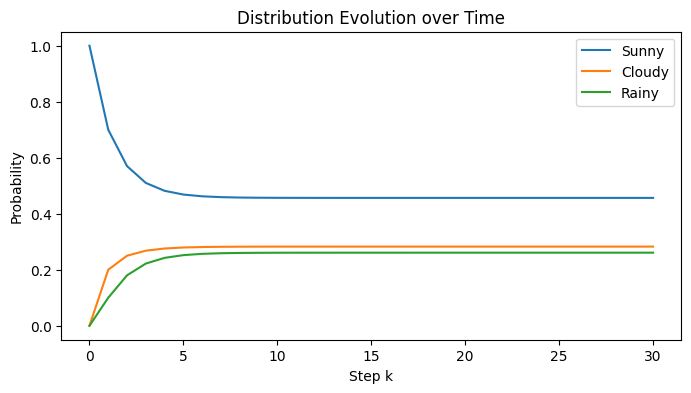

pi^(10) = [0.45680544 0.28253268 0.26066188]
pi^(30) = [0.45652174 0.2826087  0.26086957]


In [ ]:

pi0 = np.array([1.0, 0.0, 0.0])
K = 30

traj = np.zeros((K+1, len(states)))
traj[0] = pi0
for k in range(1, K+1):
    traj[k] = traj[k-1] @ P

plt.figure(figsize=(8, 4))
for j in range(len(states)):
    plt.plot(range(K+1), traj[:, j], label=states[j])
plt.xlabel("Step k")
plt.ylabel("Probability")
plt.title("Distribution Evolution over Time")
plt.legend(loc="best")
plt.show()

print("pi^(10) =", traj[10])
print("pi^(30) =", traj[30])



### 2.2 Stationary Distribution and Convergence

For an irreducible and aperiodic finite Markov chain, there exists a unique stationary distribution pi* satisfying
pi* P = pi*, with entries summing to 1. We solve a linear system and estimate via long-run simulation.


In [ ]:

def stationary_distribution(P, atol=1e-12):
    try:
        P = np.asarray(P, dtype=float)
        m = P.shape[0]
        A = P.T - np.eye(m)
        # Replace last equation with sum-to-1
        A[-1, :] = np.ones(m)
        b = np.zeros(m); b[-1] = 1.0
        pi = nla.lstsq(A, b, rcond=None)[0]
        pi = np.clip(pi, 0.0, 1.0)
        return normalize_distribution(pi, atol=atol)
    except Exception as e:
        _err("stationary_distribution", e)
        raise

pi_star = stationary_distribution(P)
print("Stationary distribution:", pi_star)
print("Check pi* P:", pi_star @ P)


Stationary distribution: [0.45652174 0.2826087  0.26086957]
Check pi* P: [0.45652174 0.2826087  0.26086957]


Empirical stationary (long run): [0.45544545 0.28178718 0.26276737]
Difference ||emp - pi*||_1: 0.003795614217771748


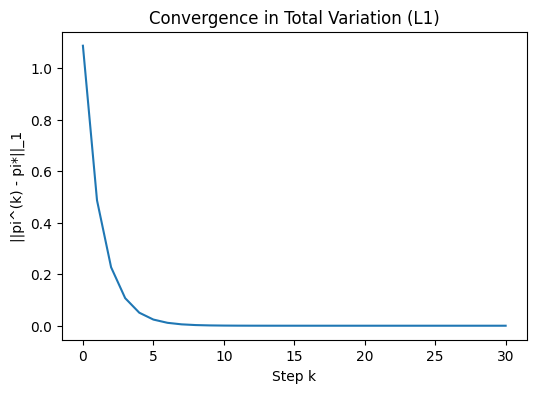

In [ ]:

def simulate_markov(P, n_steps, init_state=None, rng=None):
    try:
        rng = np.random.default_rng() if rng is None else rng
        P = np.asarray(P, dtype=float)
        m = P.shape[0]
        if init_state is None:
            init_state = int(rng.integers(low=0, high=m))
        X = np.empty(n_steps + 1, dtype=int)
        X[0] = init_state
        for t in range(n_steps):
            X[t+1] = rng.choice(m, p=P[X[t]])
        return X
    except Exception as e:
        _err("simulate_markov", e)
        raise

def empirical_stationary(P, n_steps=100_000, burn_in=1_000, rng=None):
    try:
        X = simulate_markov(P, n_steps=n_steps + burn_in, rng=rng)
        X = X[burn_in:]
        m = P.shape[0]
        counts = np.bincount(X, minlength=m)
        return counts / counts.sum()
    except Exception as e:
        _err("empirical_stationary", e)
        raise

emp_est = empirical_stationary(P, rng=rng)
print("Empirical stationary (long run):", emp_est)
print("Difference ||emp - pi*||_1:", np.abs(emp_est - pi_star).sum())

pi_norms = [np.linalg.norm(traj[k] - pi_star, ord=1) for k in range(K+1)]
plt.figure(figsize=(6, 4))
plt.plot(range(K+1), pi_norms)
plt.xlabel("Step k")
plt.ylabel("||pi^(k) - pi*||_1")
plt.title("Convergence in Total Variation (L1)")
plt.show()



### 2.3 n‑Step Transitions and Predictions

The n-step transition probabilities are $P_n$. Example: If it is Sunny today, what is the probability
it is Rainy in three days?


In [ ]:

P3 = nstep_transition(P, 3)
print("P^3 =\n", P3)

prob_rain_in_3 = P3[0, 2]  # Sunny -> Rainy in 3 steps
print("Pr[X_{t+3} = Rainy | X_t = Sunny] =", prob_rain_in_3)

pi15 = advance_distribution(pi0, P, 15)
print("pi^(15) =", pi15)


P^3 =
 [[0.51  0.268 0.222]
 [0.426 0.292 0.282]
 [0.396 0.298 0.306]]
Pr[X_{t+3} = Rainy | X_t = Sunny] = 0.222
pi^(15) = [0.45652847 0.28260689 0.26086464]



## 3. Hitting Times and First‑Step Analysis

Let T_A be the hitting time of a set of states A. We estimate $E_i[T_{j}]$ via Monte Carlo
and compare with the linear equations derived by first-step analysis for hitting a single state j.


In [ ]:

def estimate_hitting_time(P, target, start, trials=20000, rng=None, max_steps=10000):
    rng = np.random.default_rng() if rng is None else rng
    hits = []
    for _ in range(trials):
        x = start
        for t in range(max_steps):
            if x == target:
                hits.append(t)
                break
            x = rng.choice(P.shape[0], p=P[x])
    return np.mean(hits) if hits else np.inf

def hitting_time_linear_system(P, target):
    P = np.asarray(P, dtype=float)
    m = P.shape[0]
    A = np.eye(m)
    b = np.ones(m)
    A[target, :] = 0.0
    A[target, target] = 1.0
    b[target] = 0.0
    for i in range(m):
        if i == target:
            continue
        A[i, :] -= P[i, :]
    h = nla.solve(A, b)
    return h

target = 2  # Rainy
h_lin = hitting_time_linear_system(P, target)
h_mc  = [estimate_hitting_time(P, target, s, rng=rng) for s in range(P.shape[0])]
print("Expected hitting time to Rainy via linear system:", h_lin)
print("Monte Carlo estimate:", h_mc)


Expected hitting time to Rainy via linear system: [6.66666667 5.         0.        ]
Monte Carlo estimate: [np.float64(6.65115), np.float64(5.0211), np.float64(0.0)]



## 4. Absorbing Chains and the Fundamental Matrix

A state is absorbing if P[i,i]=1. After reordering states into canonical form [[Q, R],[0, I]],
the fundamental matrix is $N = (I - Q)^{-1}$. Then expected steps to absorption $t_i = \sum_j N[i,j]$,
and absorption probabilities are B = N R.


In [ ]:

states_abs = ["Start", "Middle", "AbsorbA", "AbsorbB"]
P_abs = np.array([
    [0.3, 0.6, 0.1, 0.0],
    [0.1, 0.5, 0.2, 0.2],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
], dtype=float)

absorbing = [i for i in range(P_abs.shape[0]) if np.isclose(P_abs[i, i], 1.0)]
transient = [i for i in range(P_abs.shape[0]) if i not in absorbing]
print("Transient indices:", transient, "Absorbing indices:", absorbing)

Q = P_abs[np.ix_(transient, transient)]
R = P_abs[np.ix_(transient, absorbing)]
I = np.eye(Q.shape[0])

N = nla.inv(I - Q)
t = N.sum(axis=1)
B = N @ R

print("Q =\n", Q)
print("R =\n", R)
print("N = (I - Q)^{-1} =\n", N)
print("Expected steps to absorption t =", t)
print("Absorption probabilities B =\n", B)
print("Row sums of B (should be 1):", B.sum(axis=1))


Transient indices: [0, 1] Absorbing indices: [2, 3]
Q =
 [[0.3 0.6]
 [0.1 0.5]]
R =
 [[0.1 0. ]
 [0.2 0.2]]
N = (I - Q)^{-1} =
 [[1.72413793 2.06896552]
 [0.34482759 2.4137931 ]]
Expected steps to absorption t = [3.79310345 2.75862069]
Absorption probabilities B =
 [[0.5862069  0.4137931 ]
 [0.51724138 0.48275862]]
Row sums of B (should be 1): [1. 1.]



## 5. Ergodic Theorem (Empirical Time Averages)

For an irreducible, aperiodic finite chain with stationary distribution pi*, the time-average of visits
converges almost surely to pi*. We illustrate this numerically.


In [ ]:

def time_average_distribution(P, n_steps=200000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    X = simulate_markov(P, n_steps=n_steps, rng=rng)
    m = P.shape[0]
    counts = np.bincount(X, minlength=m)
    return counts / counts.sum()

avg_est = time_average_distribution(P, rng=rng)
print("Time-average distribution:", avg_est)
print("||time-avg - pi*||_1 =", np.abs(avg_est - pi_star).sum())


Time-average distribution: [0.45893771 0.28230859 0.25875371]
||time-avg - pi*||_1 = 0.004831932362076408



## 6. (Optional) Tiny PageRank‑Style Chain

Create a small directed graph with damping factor alpha in (0,1).
With probability alpha, follow an outgoing link; with probability 1-alpha, jump uniformly.


Row sums (should be 1): [1. 1. 1. 1. 1.]
PageRank-like stationary distribution: [0.16490105 0.12811612 0.37718072 0.16490105 0.16490105]


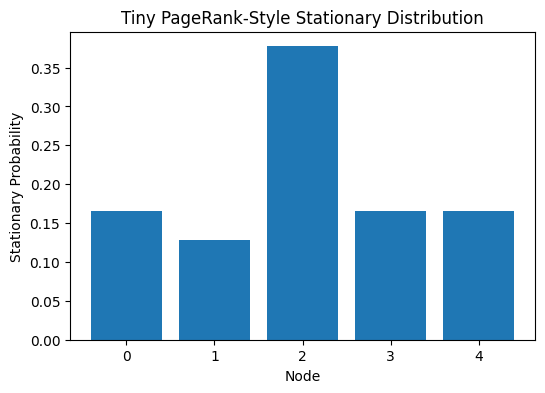

In [ ]:

def tiny_pagerank_transition(adj, alpha=0.85):
    try:
        n = len(adj)
        P = np.zeros((n, n))
        for i in range(n):
            if len(adj[i]) == 0:
                P[i, :] = 1.0 / n
            else:
                for j in adj[i]:
                    P[i, j] = 1.0 / len(adj[i])
        J = np.ones((n, n)) / n
        return alpha * P + (1 - alpha) * J
    except Exception as e:
        _err("tiny_pagerank_transition", e)
        raise

adj = [
    [1, 2],
    [2],
    [0, 3, 4],
    [2],
    []
]
P_pr = tiny_pagerank_transition(adj, alpha=0.85)
print("Row sums (should be 1):", P_pr.sum(axis=1))

pi_pr = stationary_distribution(P_pr)
print("PageRank-like stationary distribution:", pi_pr)

plt.figure(figsize=(6, 4))
plt.bar(range(len(pi_pr)), pi_pr)
plt.xlabel("Node")
plt.ylabel("Stationary Probability")
plt.title("Tiny PageRank-Style Stationary Distribution")
plt.show()


In [1]:
import numpy as np
from sklearn.preprocessing import normalize

# -------------------------------
# PageRank example using scikit-learn + NumPy
# -------------------------------

# Tiny directed web graph with 4 pages (0,1,2,3)
# A[i, j] = 1 if page i links to page j
A = np.array([
    [0, 1, 1, 0],  # 0 -> 1,2
    [0, 0, 1, 0],  # 1 -> 2
    [1, 0, 0, 1],  # 2 -> 0,3
    [0, 0, 0, 0],  # 3 -> (dangling)
], dtype=float)

n = A.shape[0]

# Handle dangling nodes: replace zero rows with ones (so they become uniform after normalization)
row_sums = A.sum(axis=1)
dangling = (row_sums == 0)
A[dangling, :] = 1.0

# Row-normalize adjacency matrix to get transition matrix P
P = normalize(A, norm="l1", axis=1)  # each row sums to 1

# Construct Google matrix G for PageRank
alpha = 0.85  # damping factor
v = np.ones(n) / n  # teleportation distribution (uniform)
G = alpha * P + (1 - alpha) * np.outer(np.ones(n), v)

# Power iteration to compute PageRank (stationary distribution of G)
def pagerank_power_iteration(G, tol=1e-8, max_iter=1000):
    n = G.shape[0]
    pi = np.ones(n) / n  # initial distribution
    for it in range(max_iter):
        pi_new = pi @ G
        if np.linalg.norm(pi_new - pi, ord=1) < tol:
            return pi_new, it + 1
        pi = pi_new
    return pi, max_iter

pi, iters = pagerank_power_iteration(G)

# Display results
print("Google matrix G:\n", G)
print("\nPageRank vector (stationary distribution):")
for i, score in enumerate(pi):
    print(f"Page {i}: {score:.4f}")
print("\nConverged in", iters, "iterations; sum(pi) =", pi.sum())


Google matrix G:
 [[0.0375 0.4625 0.4625 0.0375]
 [0.0375 0.0375 0.8875 0.0375]
 [0.4625 0.0375 0.0375 0.4625]
 [0.25   0.25   0.25   0.25  ]]

PageRank vector (stationary distribution):
Page 0: 0.2340
Page 1: 0.1867
Page 2: 0.3453
Page 3: 0.2340

Converged in 28 iterations; sum(pi) = 1.0000000000000007



## 7. Wrap‑Up and Suggestions

- Replace the example matrices with your own models (e.g., queueing systems, board games, reliability models).
- Test sensitivity by perturbing entries of P and observing effects on pi* and hitting times.
- Extend to continuous-time Markov chains (CTMCs) by introducing a generator Q and solving Kolmogorov equations.
- Consider coupling or spectral methods to study mixing rates; the L1 convergence plot above can be adapted to other norms.

References (classic):
- Norris, Markov Chains.
- Levin, Peres, Wilmer, Markov Chains and Mixing Times.
- Kemeny & Snell, Finite Markov Chains (absorbing chains).
